In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("C:\\Users\\Ayodeji\\Downloads\\orders.csv")
products = pd.read_csv("C:\\Users\\Ayodeji\\Downloads\\products.csv")
customers = pd.read_csv("C:\\Users\\Ayodeji\\Downloads\\customers.csv")


products.head()
customers.head()
orders.head()


,order_id,order_date,product_id,customer_id,quantity,unit_price,sales,region,store_type
0,1,2024-04,2,12,2,281,562,East,Physical
1,2,2023-09,8,14,7,331,2317,West,Physical
2,3,2023-10,5,16,2,132,264,South,Physical
3,4,2023-08,9,15,1,600,600,South,Online
4,5,2024-10,8,11,3,672,2016,South,Online


In [3]:
orders["month"] = pd.to_datetime(orders["order_date"])

In [4]:
df = orders.merge(products, on="product_id", how="left").merge(customers, on="customer_id", how="left")

df.head()

,order_id,order_date,product_id,customer_id,quantity,unit_price,sales,region,store_type,month,product_name,category,sub_category,cost_price,reorder_level,customer_name,segment,city,state,country
0,1,2024-04,2,12,2,281,562,East,Physical,2024-04-01,Smartphone,Technology,Phones,485,94,Customer_12,Home Office,Abuja,Ondo,Nigeria
1,2,2023-09,8,14,7,331,2317,West,Physical,2023-09-01,Keyboard,Technology,Accessories,70,49,Customer_14,Corporate,Lagos,FCT,Nigeria
2,3,2023-10,5,16,2,132,264,South,Physical,2023-10-01,Printer,Technology,Machines,156,41,Customer_16,Corporate,Lagos,FCT,Nigeria
3,4,2023-08,9,15,1,600,600,South,Online,2023-08-01,Mouse,Technology,Accessories,152,57,Customer_15,Home Office,Abuja,FCT,Nigeria
4,5,2024-10,8,11,3,672,2016,South,Online,2024-10-01,Keyboard,Technology,Accessories,70,49,Customer_11,Corporate,Abuja,FCT,Nigeria


In [5]:
category = df.groupby("category", as_index=False).agg(total_sales=("sales", "sum"), 
                                                        total_qty=("quantity", "sum")).sort_values("total_sales", ascending=False)

category

,category,total_sales,total_qty
2,Technology,794970,1769
0,Furniture,192129,438
1,Office Supplies,86537,253


In [6]:
region = df.groupby("region", as_index=False).agg(total_sales=("sales", "sum")).sort_values("total_sales", ascending=False)

region

,region,total_sales
1,North,290740
2,South,282878
3,West,270467
0,East,229551


In [7]:
segment = df.groupby("segment", as_index=False).agg(total_sales=("sales", "sum")).sort_values("total_sales", ascending=False)

segment

,segment,total_sales
2,Home Office,415399
0,Consumer,344143
1,Corporate,314094


In [8]:
top_products = (df.groupby(["product_id", "product_name"], 
                           as_index=False).agg(total_sales=("sales", "sum"),
                                               total_quantity=("quantity", "sum")).sort_values("total_sales", ascending=False))

top_products.head(3)

,product_id,product_name,total_sales,total_quantity
4,5,Printer,134770,303
7,8,Keyboard,131659,295
1,2,Smartphone,120367,275


In [9]:
top_product_id = top_products.iloc[0]["product_id"]
top_product_name = top_products.iloc[0]["product_name"]

top_product_id, top_product_name

(np.int64(5), 'Printer')

In [10]:
top_df = df[df["product_id"] == top_product_id]

monthly = (top_df.groupby("month", as_index=False).agg(total_quantity=("quantity", "sum"),
                                                      total_sales=("sales", "sum")).sort_values("month"))

monthly.head()

,month,total_quantity,total_sales
0,2023-01-01,28,12499
1,2023-02-01,20,6570
2,2023-04-01,13,7913
3,2023-05-01,19,6650
4,2023-06-01,13,7940


In [11]:
monthly_ts = monthly.set_index("month")

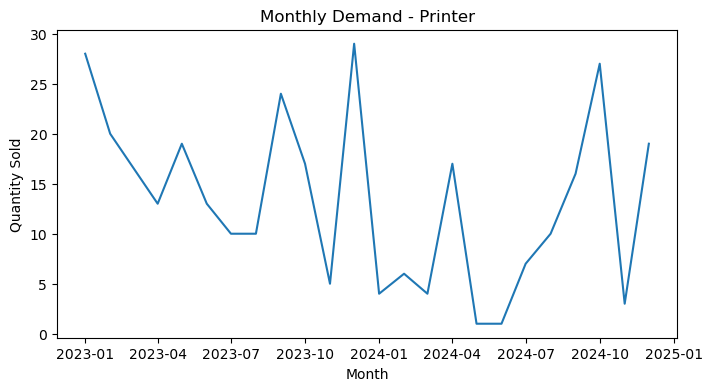

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(monthly_ts.index, monthly_ts["total_quantity"])
plt.title(f"Monthly Demand - {top_product_name}")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.show()

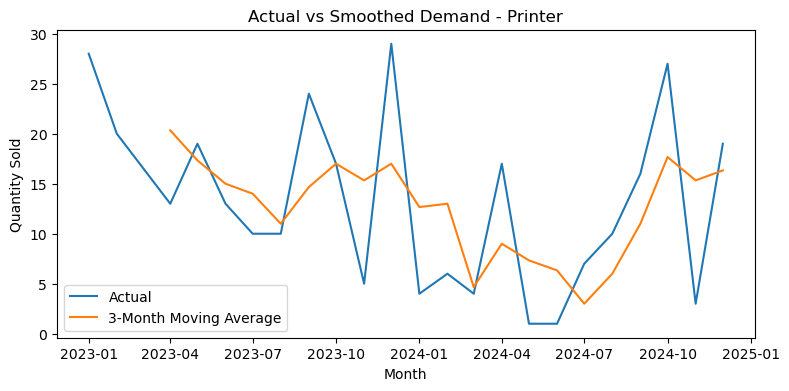

In [13]:
monthly_ts["ma_3"] = monthly_ts["total_quantity"].rolling(window=3).mean()

plt.figure(figsize=(9,4))
plt.plot(monthly_ts["total_quantity"], label="Actual")
plt.plot(monthly_ts["ma_3"], label="3-Month Moving Average")
plt.title(f"Actual vs Smoothed Demand - {top_product_name}")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(monthly_ts["total_quantity"], label="Actual")
plt.plot(monthly_ts["ma_3"], label="3-Month Moving Average")
plt.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\Ayodeji\\Downloads\\moving-average.jpg", dpi=150)
plt.close()